# L6d Extra: Synthetic Data Diagnostics (Optional)
This optional notebook contains exploratory analysis moved out of the main L6d lab. If time permits, use it to generate synthetic return paths and compare distribution and autocorrelation diagnostics.

> __Learning objectives:__
> 
> By the end of this notebook, you should be able to:
> * __Build a synthetic return generator from stored market memories:__ Set up the memory matrix and run the low-beta Hopfield model in generative mode. Initialize from a random query and produce a synthetic return path across tickers.
> * __Evaluate whether generated returns reproduce core stylized facts:__ Compare generated and observed return distributions for a selected ticker. Compute and interpret autocorrelation for returns and squared returns.
> * __Connect modeling controls to observed diagnostics:__ Adjust mixture, query, and volatility controls in the generator and inspect how diagnostics change. Use these comparisons to decide whether the synthetic path is plausible for this dataset.

Let's get started!
___

## Setup, Data, and Prerequisites
> __Environment Setup__
> 
> We include `Include.jl` so the notebook has paths, package imports, and helper methods. This keeps the remaining cells focused on the modeling workflow.

The code cell below returns `nothing::Nothing` and applies side effects by evaluating `Include.jl` in global scope.


In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

> __Package Dependency__
> 
> We use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl) for data handling and diagnostics used in this notebook. The package documentation lists the functions and types called below.

Next, we load and clean the market dataset.


### Data
> __Load and Prepare the Market Dataset__
> 
> The source dataset contains daily open-high-low-close records for S&P 500 firms plus selected ETFs and volatility products from `01-03-2014` through `12-31-2024`. We load this dictionary and then keep only tickers with a full history.

The code cell below returns `original_dataset::Dict{String,DataFrame}`, where each key is a ticker symbol and each value is that ticker's historical market dataframe.


In [2]:
original_dataset = MyTrainingMarketDataSet() |> x -> x["dataset"]; # load the original dataset

> __Reference Trading-Day Count__
> 
> Some tickers have shorter histories because of listing changes, delisting events, or corporate actions. We use `AAPL` to set a reference count for the maximum number of trading days.

The code cell below returns `maximum_number_trading_days::Int64`, which is the reference row count used to filter ticker histories.


In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # nrow? (check out: DataFrames.jl)

2767

> __Filter to Full-Length Histories__
> 
> We iterate over the raw dataset and keep only tickers whose row count matches `maximum_number_trading_days`. This creates a consistent panel with aligned time length across firms.

The code cell below returns `dataset::Dict{String,DataFrame}`, which stores only full-length ticker histories.


In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # what is this doing?
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

> __Ticker Universe__
> 
> After filtering, we extract ticker symbols and sort them alphabetically to fix a stable column order. This order is reused when we build matrices and diagnostics.

The code cell below returns `list_of_tickers::Vector{String}`, where each element is one ticker symbol.


In [5]:
list_of_tickers = keys(dataset) |> collect |> sort # list of firm "ticker" symbols in alphabetical order

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 ⋮
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

## Task 1: Compute the growth rate matrix
> __Continuously Compounded Growth Rate (CCGR):__
> 
> For firm $i$, we model the one-step price update as
> $$
> \begin{align*}
> S^{(i)}_{j} &= S^{(i)}_{j-1}\exp\left(g^{(i)}_{j,j-1}\Delta t_j\right)
> \end{align*}
> $$
> Here, $S^{(i)}_{j-1}$ and $S^{(i)}_{j}$ are consecutive prices, and $\Delta t_j=t_j-t_{j-1}$ is the step size in years. We estimate the return term $g^{(i)}_{j,j-1}\Delta t_j$ from data with [the `log_growth_rate(...)` function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/data/#VLDataScienceMachineLearningPackage.log_growth_matrix).

The code block below returns `G::Matrix{Float64}`, where each row is a trading day and each column is a ticker growth rate.


In [6]:
G = let

    # initialize -
    r̄ = 0.0; # assume the risk-free rate is 0
    Δt = (1/252); # time step size (units: years)

    # compute the growth matrix -
    growth_rate_array = log_growth_matrix(dataset, list_of_tickers, Δt = Δt, 
        risk_free_rate = r̄); # other optional parameters are at their defaults
    
    growth_rate_array; # return
end;

> __Memory Matrix Construction__
> 
> Each memory vector is one market day across all tickers, so we place daily vectors on columns. We center each memory by subtracting its cross-ticker mean and then scale it to unit 2-norm.

The code block below returns `(memories::Matrix{Float64}, scaled_memories::Matrix{Float64})`. The matrix `memories` stores raw daily vectors on columns, and `scaled_memories` stores centered, unit-norm versions of those same columns.


In [7]:
memories, scaled_memories = let

    # initialize -
    ϵ = 1e-12; # small number to avoid division by zero
    memories = transpose(G) |> Matrix; # each column is a memory vector (day in the market), and each row is a feature (a firm in the dataset)
    (number_of_rows, number_of_columns) = size(memories); # get the dimensions of the memories array

    # scale the memories to have zero-mean, and unit length
    scaled_memories = zeros(number_of_rows, number_of_columns);
    for i in 1:number_of_columns
        memory = memories[:,i]; # unscaled memory vector (day in the market)
        mean_memory = mean(memory); # what was the mean value for the growth rate that day (across all firms)?
        memory_centered = memory .- mean_memory; # center the memory vector by subtracting the mean value
        norm_memory_centered = norm(memory_centered) + ϵ; # compute the norm of the centered memory vector, and add a small number to avoid division by zero
        scaled_memories[:,i] = memory_centered ./ (norm_memory_centered + ϵ); # scale the memory vector to have unit length
    end
   
    # return -
    (memories, scaled_memories);
end;

## Task 2: Let's run the Hopfield model in generative mode
> __Generative Hopfield Model__
> 
> We run the modern Hopfield network in generative mode with a low beta value so retrieval remains diffuse rather than deterministic. The model then produces mixture weights over stored memories instead of copying one historical day.

The code block below returns `generative_model::MyModernHopfieldNetworkModel`, which is the low-beta model instance used for synthesis.


In [8]:
generative_model = build(MyModernHopfieldNetworkModel, (
    memories = memories, # raw memories on columns
    normalized_memories = scaled_memories, # normalized memories on columns
    β = 0.3, # small beta -> high temperature -> diffuse probabilities (generative mode)
));

> __Random Initial Query for Generative Mode__
> 
> We do not start from a known market day. Instead, we sample a seed vector $s\in\mathbb{R}^{N}$, where $N$ is the number of firms and each entry satisfies $s_i\sim Z(0,1)$ for $i=1,\ldots,N$.
> 
> We then normalize with $\tilde{s}=\frac{s}{\|s\|_2+\epsilon}$, where $\epsilon>0$ is a small constant used to avoid division by zero. Next, we rescale by $\hat{s}_2=\alpha\tilde{s}$, where $\alpha=\frac{1}{K}\sum_{j=1}^{K}\|m_j\|_2$, $K$ is the number of stored memories, and $m_j$ is memory $j$.
> 
> This gives an initial query with a realistic magnitude while remaining independent of any specific historical day. Under low beta, this encourages a mixture over memories.

The code block below returns `ŝ₂::Vector{Float64}`, the random initial query used in generative mode.


In [9]:
ŝ₂ = let

    # Build a random query with a comparable scale to the stored market memories
    
    # initialize -
    number_of_features = size(memories, 1); # how many firms (features) do we have in our dataset?
    target_norm = mean(norm(memories[:, i]) for i ∈ 1:size(memories, 2)); # "scale" of the memories (average norm of the memory vectors)
    
    # create a random vector with the same number of features as the memories, and a norm comparable to the memories
    s = randn(number_of_features); # random vector, standard normal distribution
    s ./= (norm(s) + 1e-12); # normalize the random vector to have unit length (add a small number to avoid division by zero)
    s .*= target_norm; # scale the random vector to have a norm comparable to the memories

    s; # return the random query vector
end;

### Let's generate synthetic market data
> __Synthetic Path Generation__
> 
> We iterate the generative update to create a synthetic return matrix with the same number of days as the filtered dataset. Each generated row is one synthetic day across the full ticker set.

The code block below returns `Ĝ::Matrix{Float64}` with dimensions `(number_of_synthetic_days, number_of_synthetic_firms)`, where each row is one synthetic day and each column is one ticker.


In [10]:
Ĝ = let

    # initialize -
    number_of_synthetic_days = maximum_number_trading_days; # how many synthetic days to generate
    number_of_synthetic_firms = length(list_of_tickers); # number of firms (features)
    sₒ = ŝ₂; # initial query state
    Ĝ = Array{Float64,2}(undef, number_of_synthetic_days, number_of_synthetic_firms);

    # memory-mixture controls -
    k = 25; # top-k support for memory mixing
    γ_sharpen = 4.0; # sharpen q to reduce over-smoothing
    λ_q = 0.00; # keep near 0 to avoid strong raw-return autocorrelation
    σ_select = 1e-5; # small jitter for stochastic tie-breaking in top-k

    # query-state controls -
    λ_query = 0.00; # keep near 0 for weak raw-return autocorrelation
    σ_query = 0.10; # additive noise in query evolution

    # latent volatility state h_t (AR(1) in log-vol) -
    ρ_logh = 0.98; # volatility persistence
    σ_logh = 0.30; # volatility shock scale (increase for stronger clustering)
    logh = 0.0;

    # optional post-adjustments -
    match_ticker_means = true;  # shift generated per-ticker means to match original means
    match_ticker_stds = true;  # keep false when evaluating volatility clustering
    α_std = 1.0; # partial std scaling if match_ticker_stds=true

    # constants -
    M = memories; # raw memories on columns (features x memory_index)
    number_of_memories = size(M, 2);
    μ_orig = vec(mean(G, dims=1));
    σ_orig = vec(std(G, dims=1));
    q_prev = fill(1.0/number_of_memories, number_of_memories);

    for t ∈ 1:number_of_synthetic_days

        # recover probabilities over memories from current query
        (m̂, f, p) = recover(generative_model, sₒ, maxiterations = 100, ϵₚ = 1e-12, ϵₛ = 5e-1);
        last_probability = p[length(f) - 1];

        # stochastic top-k proposal q_new
        selection_scores = last_probability .+ σ_select*randn(length(last_probability));
        sorted_idx = sortperm(selection_scores, rev=true);
        keep = sorted_idx[1:min(k, length(sorted_idx))];

        q_new = zeros(length(last_probability));
        q_new[keep] = last_probability[keep];
        q_new ./= (sum(q_new) + 1e-12);

        # sticky mixture weights for temporal persistence
        q = λ_q*q_prev + (1 - λ_q)*q_new;
        q ./= (sum(q) + 1e-12);

        # sharpen then renormalize
        q .^= γ_sharpen;
        q ./= (sum(q) + 1e-12);

        # base generated vector from memory mixture
        m_raw = M*q;

        # latent volatility update: log h_t = ρ log h_{t-1} + σ ε_t
        logh = ρ_logh*logh + σ_logh*randn();
        h = exp(logh);

        # apply scalar volatility modulation around per-ticker historical mean
        m_topk = μ_orig .+ sqrt(h).*(m_raw .- μ_orig);

        # store generated day
        Ĝ[t, :] = m_topk;

        # evolve query state with persistence + noise (do not hard-normalize)
        sₒ = λ_query*sₒ + (1 - λ_query)*m_topk + σ_query*randn(length(m_topk));

        # carry state
        q_prev = q;
    end

    # optional first/second-moment matching per ticker
    if match_ticker_means || match_ticker_stds
        μ_gen = vec(mean(Ĝ, dims=1));
        σ_gen = vec(std(Ĝ, dims=1));

        if match_ticker_stds
            scale = (σ_orig ./ (σ_gen .+ 1e-12)) .^ α_std;
            Ĝ .-= reshape(μ_gen, 1, :);
            Ĝ .*= reshape(scale, 1, :);
            Ĝ .+= reshape(μ_orig, 1, :);
        elseif match_ticker_means
            Ĝ .+= reshape(μ_orig .- μ_gen, 1, :);
        end
    end

    println("Generated days: ", number_of_synthetic_days, ", unique rows (rounded 1e-10): ", length(unique(eachrow(round.(Ĝ, digits=10)))));
    println("Mean alignment check (avg |Δμ|): ", mean(abs.(vec(mean(Ĝ, dims=1)) .- μ_orig)));
    println("Std alignment check (avg |Δσ|): ", mean(abs.(vec(std(Ĝ, dims=1)) .- σ_orig)), " (α_std = ", α_std, ")");

    Ĝ;
end

Generated days: 2767, unique rows (rounded 1e-10): 2767
Mean alignment check (avg |Δμ|): 7.333588882872521e-17
Std alignment check (avg |Δσ|): 3.0922078315089527e-12 (α_std = 1.0)


2767×424 Matrix{Float64}:
 -2.98868     -2.18955     2.7299    …  -4.5423      -3.31236    0.0210032
  1.83516      6.0731      2.01495       4.24719      4.52592   -1.70966
  1.41789      9.52861     6.16431       1.55933      6.93064    1.88498
  0.916829     4.30765     0.161599      0.812097     1.64487    1.49359
 -0.156608    -2.2604      0.442733      3.31666     -0.112303  -1.61532
 -3.48544      0.583974    2.03602   …  -1.11348     -4.72228   -1.16319
  3.1034       0.328117    1.0319        2.60748      2.4613     2.10824
 -0.326814    -2.34761    -0.941064     -1.25782      1.85525   -1.95773
 -3.42427      6.081      -3.95443       2.80873      3.15394   -1.31948
  0.550139     1.03478     4.80482      -1.02007      1.53795    2.33994
  ⋮                                  ⋱                          
  3.03285     -3.04582    -2.92379      -0.543831    -1.21005   -4.60458
  2.77029     -2.62936    -0.881618     -2.14207     -2.80243    2.29908
 -0.359669    -0.0591693   3.68

## Task 3: Let's compute the stylized facts for our synthetic data
> __Stylized-Fact Diagnostics__
> 
> We compare generated and observed data using three checks: heavy-tailed return distributions, autocorrelation of returns, and autocorrelation of squared returns. These checks test whether the generator captures tail risk, weak linear dependence, and volatility clustering.

For a direct comparison, we first choose one ticker symbol and use it in all three plots below.


In [15]:
ticker_to_compare = "TSLA"; # which ticker do we want to compare between the original and generated data?

### Heavy-tailed return distributions
> __Distribution Comparison__
> 
> Heavy tails mean large return moves occur more often than a normal model predicts. We compare kernel density curves for one ticker in observed and generated data.

The code cell below plots the observed and generated return densities for `ticker_to_compare`.


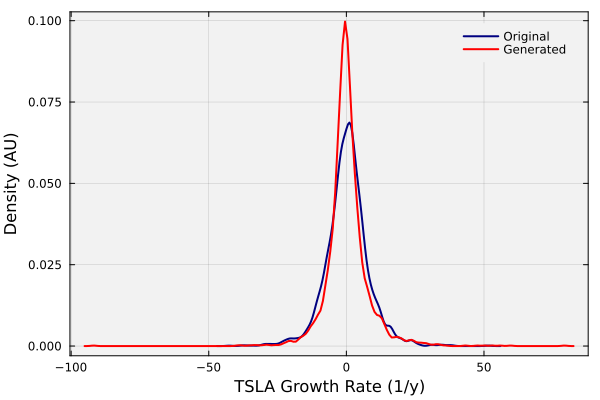

In [16]:
let

    # initialize -
    ticker_index = findfirst(==(ticker_to_compare), list_of_tickers); # find the index of the ticker we want to compare

    # let's plot the return distribution -
    density(G[:, ticker_index], label="Original", xlabel="$(ticker_to_compare) Growth Rate (1/y)", ylabel="Density (AU)",
        color=:navy, lw=2)
    density!(Ĝ[:, ticker_index], label="Generated", color=:red, lw=2)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
end

### Auto-correlation structure of the generated data
> __Return Autocorrelation Check__
> 
> We compute lag autocorrelation for observed returns and generated returns of the same ticker. This checks whether short-lag linear dependence is similar across both series.

The code cell below plots both autocorrelation curves with 99% confidence reference bounds.


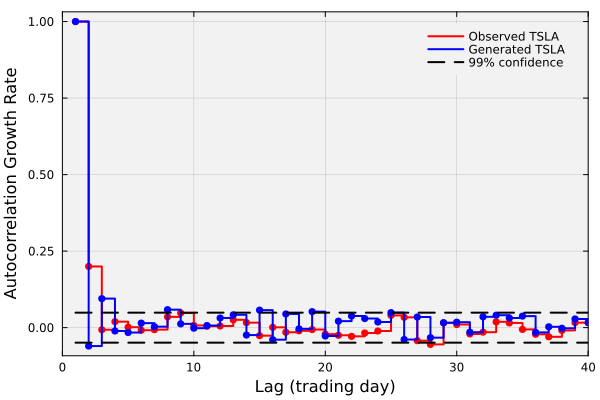

In [17]:
let

    # generate a random index -
    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    number_of_steps = maximum_number_trading_days - 1;
    max_number_of_steps_x = 40
    X = G[:,i]; # observed data for the selected ticker
    X̂ = Ĝ[:,i]; # this is the generated data for the same ticker
    
    # Observed autocorrelation for the original data
    plot(autocor(X, (0:(number_of_steps - 1) |> collect)), label="Observed $(ticker_to_compare)", lw=2, c=:red, 
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, 
        linetype=:steppost, xlims=(0,max_number_of_steps_x))
    scatter!(autocor(X, (0:(number_of_steps - 1) |> collect)), label="", c=:red, msc=:red)
    
    # Autocorrelation for the generated data
    plot!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="Generated $(ticker_to_compare)", lw=2, c=:blue, linetype=:steppost)
    scatter!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="", c=:blue, msc=:blue)
    
    # Confidence intervals for null hypothesis of no autocorrelation (dashed lines)
    LINE = (2.576/sqrt(number_of_steps))*ones(number_of_steps-1);
    plot!(LINE, label="99% confidence", lw=2, c=:black, ls=:dash)
    plot!(-LINE, label="", lw=2, c=:black, ls=:dash)
    xlabel!("Lag (trading day)", fontsize=18)
    ylabel!("Autocorrelation Growth Rate", fontsize=18)

    # uncomment me to save to file -
    # savefig(joinpath(_PATH_TO_FIGS, "Fig-Autocorrelation-HMM-GenModel-$(ticker_to_compare).pdf"));
end

### Volatility clustering
> __Squared-Return Autocorrelation Check__
> 
> Volatility clustering appears when large-magnitude returns tend to follow large-magnitude returns. We proxy this behavior by autocorrelation of squared returns.

The code cell below compares squared-return autocorrelation for observed and generated data.


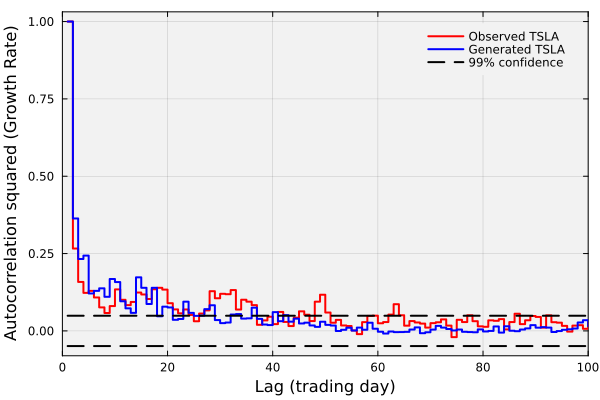

In [18]:
let

    # generate a random index -
    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    number_of_steps = maximum_number_trading_days - 1;
    max_number_of_steps_x = 100
    X = (G[:,i]).^2;
    X̂ = (Ĝ[:,i]).^2;

    plot(autocor(X, (0:(number_of_steps - 1) |> collect)), label="Observed $(ticker_to_compare)", lw=2, c=:red,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, linetype=:steppost,
    xlims=(0,max_number_of_steps_x))

    plot!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="Generated $(ticker_to_compare)", lw=2, c=:blue,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, linetype=:steppost,
    xlims=(0,max_number_of_steps_x))
    
    LINE = (2.576/sqrt(number_of_steps))*ones(number_of_steps-1);
    plot!(LINE, label="99% confidence", lw=2, c=:black, ls=:dash)
    plot!(-LINE, label="", lw=2, c=:black, ls=:dash)
    xlabel!("Lag (trading day)", fontsize=18)
    ylabel!("Autocorrelation squared (Growth Rate)", fontsize=18)

    
    # uncomment me to save to file -
    # savefig(joinpath(_PATH_TO_FIGS, "Fig-Autocorrelation-HMM-GenModel-$(ticker_to_compare).pdf"));
end

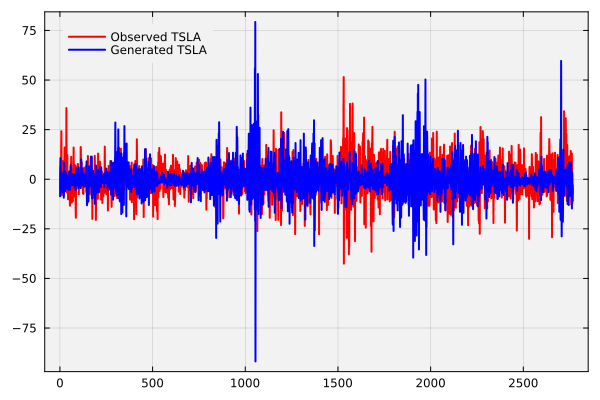

In [20]:
let

    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    X = G[:,i];
    X̂ = Ĝ[:,i];

    plot(X, label="Observed $(ticker_to_compare)", lw=2, c=:red, bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    plot!(X̂, label="Generated $(ticker_to_compare)", lw=2, c=:blue, bg="gray95", background_color_outside="white", framestyle = :box)
end

## Summary
This notebook builds a synthetic multi-ticker return path from stored market memories and then evaluates whether the generated path reproduces three core diagnostics.

> __Key takeaways:__
> 
> * **Generator setup matters:** The synthetic path is produced by iterating a low-beta Hopfield memory-mixture update from a random query state. Mixture, persistence, and volatility controls shape the statistical behavior seen in the generated returns.
> * **Diagnostics must be compared side by side:** Distribution, return-autocorrelation, and squared-return-autocorrelation plots provide complementary checks on model behavior. No single plot is sufficient to judge whether the generator is credible.
> * **Post-calibration should be interpreted carefully:** Optional mean and standard-deviation matching can improve alignment to historical moments. These adjustments do not replace the need for acceptable dynamics before calibration.

___
